In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed so results are reproducible every time you run it
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
class Perceptron:
    def __init__(self, input_size, learning_rate=0.1):
        # Initialize weights and bias randomly
        self.weights = np.random.rand(input_size)
        self.bias = np.random.rand()
        self.learning_rate = learning_rate
        self.error_history = []  # To store error count per epoch for plotting

    def step_function(self, z):
        """Activation Function: Returns 1 if z >= 0, else 0"""
        return 1 if z >= 0 else 0

    def predict(self, x):
        """Calculate weighted sum and apply activation"""
        z = np.dot(self.weights, x) + self.bias
        return self.step_function(z)

    def train(self, X, Y, epochs=20, gate_name=""):
        print(f"--- Starting Training for {gate_name} Gate ---")
        print(f"Initial Weights: {self.weights}, Initial Bias: {self.bias:.4f}\n")

        for epoch in range(epochs):
            epoch_error = 0

            # Iterate over each sample in the dataset
            for i in range(len(X)):
                x = X[i]
                y = Y[i]

                # Forward Pass
                y_hat = self.predict(x)

                # Calculate Error
                error = y - y_hat

                # Update Weights and Bias if there is an error
                if error != 0:
                    # Weight Update Rule: w = w + η * (y - ŷ) * x
                    self.weights = self.weights + self.learning_rate * error * x
                    # Bias Update Rule: b = b + η * (y - ŷ)
                    self.bias = self.bias + self.learning_rate * error
                    epoch_error += 1

            # Store error count for this epoch for plotting
            self.error_history.append(epoch_error)

            # Print weights and bias after every epoch
            print(f"Epoch {epoch+1:02d} | Errors: {epoch_error} | Weights: {self.weights} | Bias: {self.bias:.4f}")

        print(f"--- Training Completed for {gate_name} Gate ---\n")

print("Perceptron Class defined successfully!")

Perceptron Class defined successfully!


In [ ]:
# --- Dataset Creation ---
# Inputs
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Targets
Y_OR  = np.array([0, 1, 1, 1])
Y_AND = np.array([0, 0, 0, 1])

# --- Configuration ---
EPOCHS = 20
LEARNING_RATE = 0.1

print("Dataset and Parameters configured!")
print(f"Inputs: {X}")
print(f"OR Targets: {Y_OR}")
print(f"AND Targets: {Y_AND}")

Dataset and Parameters configured!
Inputs: [[0 0]
 [0 1]
 [1 0]
 [1 1]]
OR Targets: [0 1 1 1]
AND Targets: [0 0 0 1]


In [ ]:
# 1. Train for OR Gate
perceptron_or = Perceptron(input_size=2, learning_rate=LEARNING_RATE)
perceptron_or.train(X, Y_OR, epochs=EPOCHS, gate_name="OR")

# 2. Train for AND Gate
perceptron_and = Perceptron(input_size=2, learning_rate=LEARNING_RATE)
perceptron_and.train(X, Y_AND, epochs=EPOCHS, gate_name="AND")

print("Both models trained!")

--- Starting Training for OR Gate ---
Initial Weights: [0.37454012 0.95071431], Initial Bias: 0.7320

Epoch 01 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: 0.6320
Epoch 02 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: 0.5320
Epoch 03 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: 0.4320
Epoch 04 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: 0.3320
Epoch 05 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: 0.2320
Epoch 06 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: 0.1320
Epoch 07 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: 0.0320
Epoch 08 | Errors: 1 | Weights: [0.37454012 0.95071431] | Bias: -0.0680
Epoch 09 | Errors: 0 | Weights: [0.37454012 0.95071431] | Bias: -0.0680
Epoch 10 | Errors: 0 | Weights: [0.37454012 0.95071431] | Bias: -0.0680
Epoch 11 | Errors: 0 | Weights: [0.37454012 0.95071431] | Bias: -0.0680
Epoch 12 | Errors: 0 | Weights: [0.37454012 0.95071431] | Bias: -0.0680
Epoch 13 | Errors: 0 | Weights: [0.374540

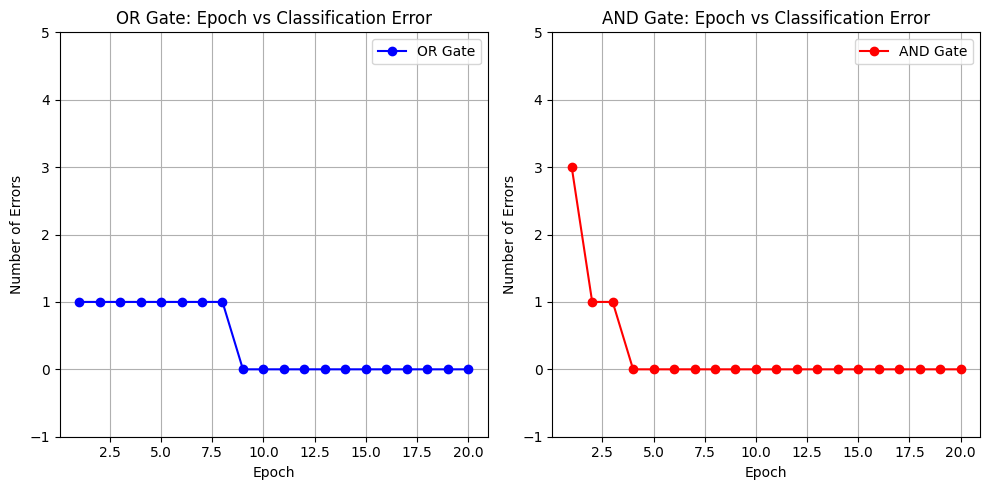

In [ ]:
plt.figure(figsize=(10, 5))

# Plot OR Gate Error
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), perceptron_or.error_history, marker='o', color='blue', label='OR Gate')
plt.title('OR Gate: Epoch vs Classification Error')
plt.xlabel('Epoch')
plt.ylabel('Number of Errors')
plt.ylim(-1, 5) # Set y-limit for better visibility
plt.grid(True)
plt.legend()

# Plot AND Gate Error
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), perceptron_and.error_history, marker='o', color='red', label='AND Gate')
plt.title('AND Gate: Epoch vs Classification Error')
plt.xlabel('Epoch')
plt.ylabel('Number of Errors')
plt.ylim(-1, 5) # Set y-limit for better visibility
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def display_predictions(model, X, Y, gate_name):
    print(f"--- Final Predictions ({gate_name} Gate) ---")
    print(f"{'Input':<10} | {'Target':<10} | {'Prediction':<10}")
    print("-" * 35)
    for i in range(len(X)):
        pred = model.predict(X[i])
        target = Y[i]
        status = "✅" if pred == target else "❌"
        print(f"{str(X[i]):<10} | {target:<10} | {pred:<10} {status}")
    print("\n")

# Display OR Results
display_predictions(perceptron_or, X, Y_OR, "OR")

# Display AND Results
display_predictions(perceptron_and, X, Y_AND, "AND")

--- Final Predictions (OR Gate) ---
Input      | Target     | Prediction
-----------------------------------
[0 0]      | 0          | 0          ✅
[0 1]      | 1          | 1          ✅
[1 0]      | 1          | 1          ✅
[1 1]      | 1          | 1          ✅


--- Final Predictions (AND Gate) ---
Input      | Target     | Prediction
-----------------------------------
[0 0]      | 0          | 0          ✅
[0 1]      | 0          | 0          ✅
[1 0]      | 0          | 0          ✅
[1 1]      | 1          | 1          ✅




In [ ]:
# Replace with your repository HTTPS URL
!git clone https://github.com/your-username/your-repo-name.git

**Q2---->**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Install tabulate if not available (for nice table formatting)
!pip install tabulate -q

In [3]:
# Generate 150 values between -10 and 10
x = np.linspace(-10, 10, 150)

print(f"Input values shape: {x.shape}")
print(f"Range: [{x.min()}, {x.max()}]")
print(f"First 10 values: {x[:10]}")

Input values shape: (150,)
Range: [-10.0, 10.0]
First 10 values: [-10.          -9.86577181  -9.73154362  -9.59731544  -9.46308725
  -9.32885906  -9.19463087  -9.06040268  -8.9261745   -8.79194631]


In [4]:
def sigmoid(x):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-x))

def relu(x):
    """ReLU (Rectified Linear Unit) activation function"""
    return np.maximum(0, x)

def tanh(x):
    """Hyperbolic Tangent activation function"""
    return np.tanh(x)

def leaky_relu(x, alpha=0.01):
    """Leaky ReLU activation function"""
    return np.where(x > 0, x, alpha * x)

# Test the functions
print("Testing activation functions at x = [−2, 0, 2]:")
test_x = np.array([-2, 0, 2])
print(f"Sigmoid: {sigmoid(test_x)}")
print(f"ReLU: {relu(test_x)}")
print(f"Tanh: {tanh(test_x)}")
print(f"Leaky ReLU: {leaky_relu(test_x)}")

Testing activation functions at x = [−2, 0, 2]:
Sigmoid: [0.11920292 0.5        0.88079708]
ReLU: [0 0 2]
Tanh: [-0.96402758  0.          0.96402758]
Leaky ReLU: [-0.02  0.    2.  ]


In [5]:
# Compute outputs for all activation functions
sigmoid_out = sigmoid(x)
relu_out = relu(x)
tanh_out = tanh(x)
leaky_relu_out = leaky_relu(x)

# Display sample outputs
print("Sample outputs (first 10 values):")
print(f"{'x':<8} {'Sigmoid':<10} {'ReLU':<8} {'Tanh':<10} {'Leaky ReLU':<10}")
print("-" * 60)
for i in range(10):
    print(f"{x[i]:<8.2f} {sigmoid_out[i]:<10.4f} {relu_out[i]:<8.4f} {tanh_out[i]:<10.4f} {leaky_relu_out[i]:<10.4f}")

Sample outputs (first 10 values):
x        Sigmoid    ReLU     Tanh       Leaky ReLU
------------------------------------------------------------
-10.00   0.0000     0.0000   -1.0000    -0.1000   
-9.87    0.0001     0.0000   -1.0000    -0.0987   
-9.73    0.0001     0.0000   -1.0000    -0.0973   
-9.60    0.0001     0.0000   -1.0000    -0.0960   
-9.46    0.0001     0.0000   -1.0000    -0.0946   
-9.33    0.0001     0.0000   -1.0000    -0.0933   
-9.19    0.0001     0.0000   -1.0000    -0.0919   
-9.06    0.0001     0.0000   -1.0000    -0.0906   
-8.93    0.0001     0.0000   -1.0000    -0.0893   
-8.79    0.0002     0.0000   -1.0000    -0.0879   


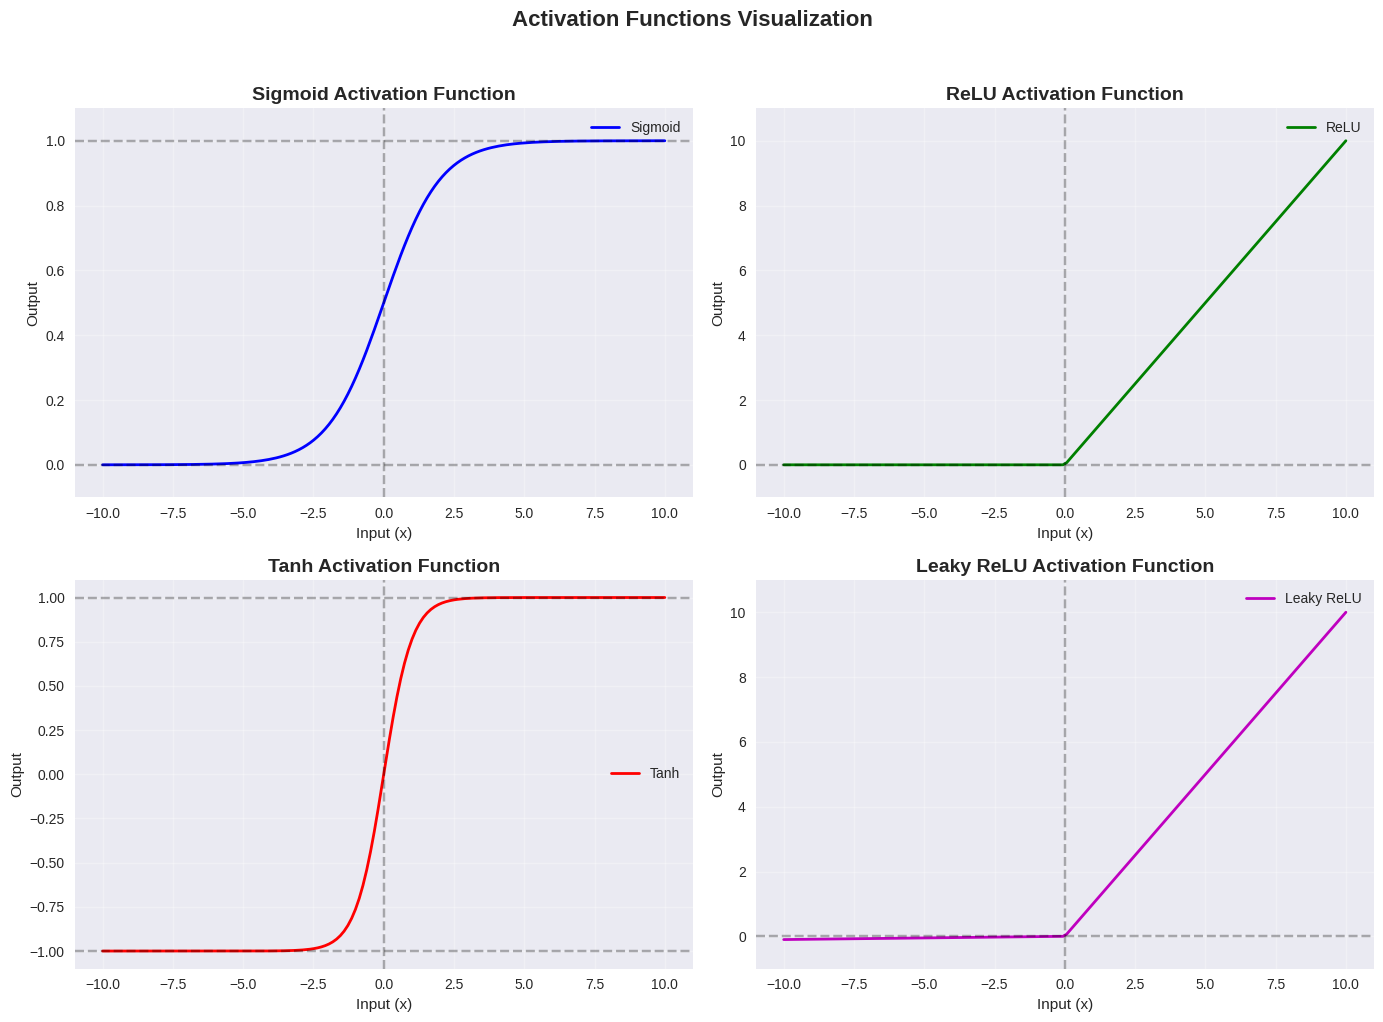

In [6]:
# Create separate graphs for each activation function
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sigmoid
axes[0, 0].plot(x, sigmoid_out, 'b-', linewidth=2, label='Sigmoid')
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].axhline(y=1, color='k', linestyle='--', alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].set_title('Sigmoid Activation Function', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Input (x)')
axes[0, 0].set_ylabel('Output')
axes[0, 0].set_ylim(-0.1, 1.1)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# ReLU
axes[0, 1].plot(x, relu_out, 'g-', linewidth=2, label='ReLU')
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_title('ReLU Activation Function', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Input (x)')
axes[0, 1].set_ylabel('Output')
axes[0, 1].set_ylim(-1, 11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Tanh
axes[1, 0].plot(x, tanh_out, 'r-', linewidth=2, label='Tanh')
axes[1, 0].axhline(y=-1, color='k', linestyle='--', alpha=0.3)
axes[1, 0].axhline(y=1, color='k', linestyle='--', alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Tanh Activation Function', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Input (x)')
axes[1, 0].set_ylabel('Output')
axes[1, 0].set_ylim(-1.1, 1.1)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Leaky ReLU
axes[1, 1].plot(x, leaky_relu_out, 'm-', linewidth=2, label='Leaky ReLU')
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Leaky ReLU Activation Function', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Input (x)')
axes[1, 1].set_ylabel('Output')
axes[1, 1].set_ylim(-1, 11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.suptitle('Activation Functions Visualization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
def sigmoid_derivative(x):
    """Derivative of Sigmoid function"""
    sig = sigmoid(x)
    return sig * (1 - sig)

def tanh_derivative(x):
    """Derivative of Tanh function"""
    return 1 - np.tanh(x) ** 2

def relu_derivative(x):
    """Derivative of ReLU function"""
    return np.where(x > 0, 1, 0)

def leaky_relu_derivative(x, alpha=0.01):
    """Derivative of Leaky ReLU function"""
    return np.where(x > 0, 1, alpha)

# Test derivatives
print("Testing derivatives at x = [−2, 0, 2]:")
test_x = np.array([-2, 0, 2])
print(f"Sigmoid Derivative: {sigmoid_derivative(test_x)}")
print(f"Tanh Derivative: {tanh_derivative(test_x)}")
print(f"ReLU Derivative: {relu_derivative(test_x)}")
print(f"Leaky ReLU Derivative: {leaky_relu_derivative(test_x)}")

Testing derivatives at x = [−2, 0, 2]:
Sigmoid Derivative: [0.10499359 0.25       0.10499359]
Tanh Derivative: [0.07065082 1.         0.07065082]
ReLU Derivative: [0 0 1]
Leaky ReLU Derivative: [0.01 0.01 1.  ]


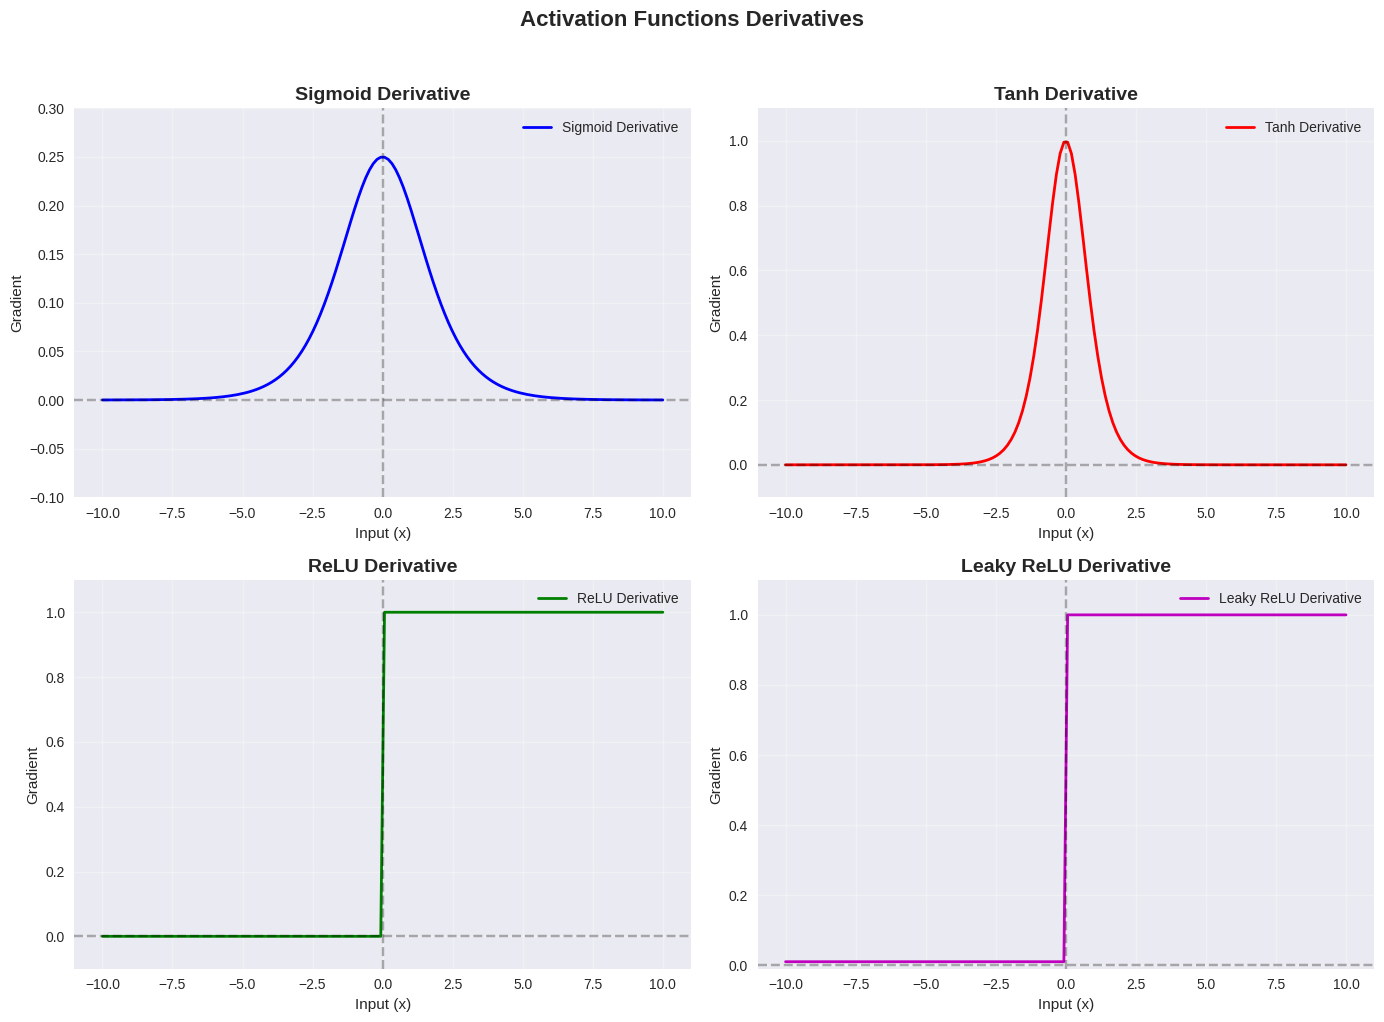

In [8]:
# Compute derivatives
sigmoid_deriv = sigmoid_derivative(x)
tanh_deriv = tanh_derivative(x)
relu_deriv = relu_derivative(x)
leaky_relu_deriv = leaky_relu_derivative(x)

# Plot derivatives
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sigmoid Derivative
axes[0, 0].plot(x, sigmoid_deriv, 'b-', linewidth=2, label='Sigmoid Derivative')
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].set_title('Sigmoid Derivative', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Input (x)')
axes[0, 0].set_ylabel('Gradient')
axes[0, 0].set_ylim(-0.1, 0.3)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Tanh Derivative
axes[0, 1].plot(x, tanh_deriv, 'r-', linewidth=2, label='Tanh Derivative')
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_title('Tanh Derivative', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Input (x)')
axes[0, 1].set_ylabel('Gradient')
axes[0, 1].set_ylim(-0.1, 1.1)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# ReLU Derivative
axes[1, 0].plot(x, relu_deriv, 'g-', linewidth=2, label='ReLU Derivative')
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].set_title('ReLU Derivative', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Input (x)')
axes[1, 0].set_ylabel('Gradient')
axes[1, 0].set_ylim(-0.1, 1.1)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Leaky ReLU Derivative
axes[1, 1].plot(x, leaky_relu_deriv, 'm-', linewidth=2, label='Leaky ReLU Derivative')
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Leaky ReLU Derivative', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Input (x)')
axes[1, 1].set_ylabel('Gradient')
axes[1, 1].set_ylim(-0.01, 1.1)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.suptitle('Activation Functions Derivatives', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Create comparison table
print("=" * 80)
print("ACTIVATION FUNCTIONS COMPARISON")
print("=" * 80)

comparison_data = {
    'Function': ['Sigmoid', 'ReLU', 'Tanh', 'Leaky ReLU'],
    'Output Range': ['(0, 1)', '[0, ∞)', '(-1, 1)', '(-∞, ∞)'],
    'Max Gradient': [f'{sigmoid_deriv.max():.4f}', '1.0', f'{tanh_deriv.max():.4f}', '1.0'],
    'Min Gradient': [f'{sigmoid_deriv.min():.4f}', '0.0', f'{tanh_deriv.min():.4f}', '0.01'],
    'Saturation Regions': ['x < -5, x > 5', 'x < 0', 'x < -5, x > 5', 'None'],
    'Zero-Centered': ['No', 'No', 'Yes', 'No'],
    'Vanishing Gradient': ['Yes', 'Partial', 'Yes', 'Reduced']
}

# Print as table
from tabulate import tabulate
print(tabulate(comparison_data, headers='keys', tablefmt='grid'))

print("\n" + "=" * 80)
print("DETAILED ANALYSIS")
print("=" * 80)

# Output Range Analysis
print("\n📊 OUTPUT RANGE:")
print(f"  • Sigmoid:   [{sigmoid_out.min():.4f}, {sigmoid_out.max():.4f}]")
print(f"  • ReLU:      [{relu_out.min():.4f}, {relu_out.max():.4f}]")
print(f"  • Tanh:      [{tanh_out.min():.4f}, {tanh_out.max():.4f}]")
print(f"  • Leaky ReLU:[{leaky_relu_out.min():.4f}, {leaky_relu_out.max():.4f}]")

# Gradient Behavior Analysis
print("\n📈 GRADIENT BEHAVIOR:")
print(f"  • Sigmoid Max Gradient:   {sigmoid_deriv.max():.4f} at x = {x[np.argmax(sigmoid_deriv)]:.2f}")
print(f"  • Tanh Max Gradient:      {tanh_deriv.max():.4f} at x = {x[np.argmax(tanh_deriv)]:.2f}")
print(f"  • ReLU Gradient:          Constant (0 or 1)")
print(f"  • Leaky ReLU Gradient:    0.01 (x<0) or 1 (x>0)")

# Saturation Regions Analysis
print("\n⚠️  SATURATION REGIONS:")
sigmoid_sat_left = np.sum(sigmoid_out < 0.01)
sigmoid_sat_right = np.sum(sigmoid_out > 0.99)
tanh_sat_left = np.sum(tanh_out < -0.99)
tanh_sat_right = np.sum(tanh_out > 0.99)

print(f"  • Sigmoid: {sigmoid_sat_left + sigmoid_sat_right} values saturated ({sigmoid_sat_left} left, {sigmoid_sat_right} right)")
print(f"  • Tanh:    {tanh_sat_left + tanh_sat_right} values saturated ({tanh_sat_left} left, {tanh_sat_right} right)")
print(f"  • ReLU:    {np.sum(relu_out == 0)} values at zero (dead neurons)")
print(f"  • Leaky ReLU: No saturation (always has gradient)")

ACTIVATION FUNCTIONS COMPARISON
+------------+----------------+----------------+----------------+----------------------+-----------------+----------------------+
| Function   | Output Range   |   Max Gradient |   Min Gradient | Saturation Regions   | Zero-Centered   | Vanishing Gradient   |
+============+================+================+================+======================+=================+======================+
| Sigmoid    | (0, 1)         |         0.2497 |           0    | x < -5, x > 5        | No              | Yes                  |
+------------+----------------+----------------+----------------+----------------------+-----------------+----------------------+
| ReLU       | [0, ∞)         |         1      |           0    | x < 0                | No              | Partial              |
+------------+----------------+----------------+----------------+----------------------+-----------------+----------------------+
| Tanh       | (-1, 1)        |         0.9955 |          

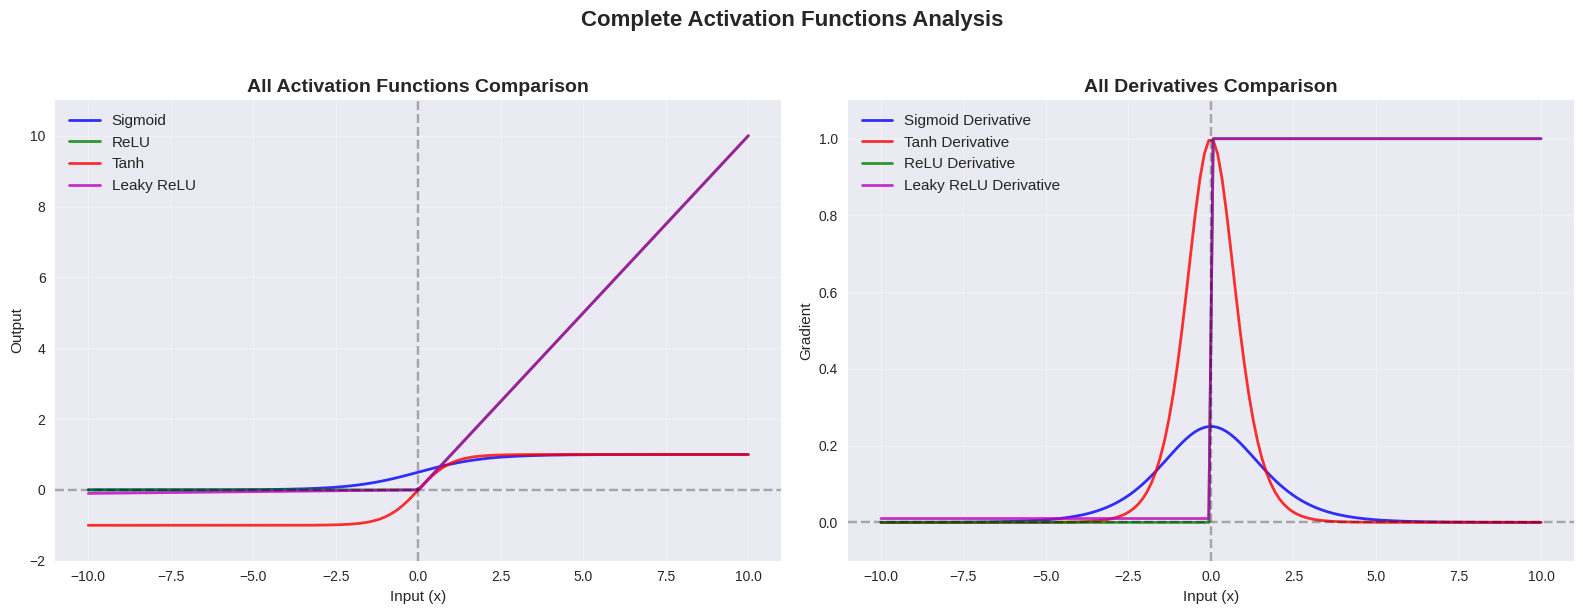

In [10]:
# Plot all activation functions together for easy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# All activation functions
ax1.plot(x, sigmoid_out, 'b-', linewidth=2, label='Sigmoid', alpha=0.8)
ax1.plot(x, relu_out, 'g-', linewidth=2, label='ReLU', alpha=0.8)
ax1.plot(x, tanh_out, 'r-', linewidth=2, label='Tanh', alpha=0.8)
ax1.plot(x, leaky_relu_out, 'm-', linewidth=2, label='Leaky ReLU', alpha=0.8)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.set_title('All Activation Functions Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('Input (x)')
ax1.set_ylabel('Output')
ax1.set_ylim(-2, 11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=11)

# All derivatives
ax2.plot(x, sigmoid_deriv, 'b-', linewidth=2, label='Sigmoid Derivative', alpha=0.8)
ax2.plot(x, tanh_deriv, 'r-', linewidth=2, label='Tanh Derivative', alpha=0.8)
ax2.plot(x, relu_deriv, 'g-', linewidth=2, label='ReLU Derivative', alpha=0.8)
ax2.plot(x, leaky_relu_deriv, 'm-', linewidth=2, label='Leaky ReLU Derivative', alpha=0.8)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.set_title('All Derivatives Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Input (x)')
ax2.set_ylabel('Gradient')
ax2.set_ylim(-0.1, 1.1)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=11)

plt.suptitle('Complete Activation Functions Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
print("=" * 80)
print("KEY TAKEAWAYS & RECOMMENDATIONS")
print("=" * 80)

print("""
🎯 WHEN TO USE EACH ACTIVATION FUNCTION:

1. SIGMOID:
   ✅ Good for: Binary classification output layer
   ❌ Avoid: Hidden layers (vanishing gradient problem)
   ⚠️  Issue: Saturates at extreme values, not zero-centered

2. ReLU:
   ✅ Good for: Most hidden layers (default choice)
   ✅ Fast computation
   ❌ Issue: Dead neurons (gradient = 0 for x < 0)
   ⚠️  Not zero-centered

3. Tanh:
   ✅ Good for: Hidden layers (better than sigmoid)
   ✅ Zero-centered output
   ❌ Issue: Still suffers from vanishing gradient
   ⚠️  Saturates at extreme values

4. Leaky ReLU:
   ✅ Good for: When ReLU has dead neuron problems
   ✅ Prevents dying ReLU problem
   ✅ Always has gradient flow
   ⚠️  Not zero-centered

📊 GRADIENT FLOW RANKING (Best to Worst):
   1. Leaky ReLU (consistent gradient)
   2. ReLU (good for positive values)
   3. Tanh (better than sigmoid)
   4. Sigmoid (prone to vanishing gradient)

💡 BEST PRACTICES:
   • Use ReLU/Leaky ReLU for hidden layers
   • Use Sigmoid for binary classification output
   • Use Tanh when zero-centered output is needed
   • Avoid Sigmoid in deep networks (vanishing gradient)
""")

print("=" * 80)
print("Code execution complete! 🎉")
print("=" * 80)

KEY TAKEAWAYS & RECOMMENDATIONS

🎯 WHEN TO USE EACH ACTIVATION FUNCTION:

1. SIGMOID:
   ✅ Good for: Binary classification output layer
   ❌ Avoid: Hidden layers (vanishing gradient problem)
   ⚠️  Issue: Saturates at extreme values, not zero-centered

2. ReLU:
   ✅ Good for: Most hidden layers (default choice)
   ✅ Fast computation
   ❌ Issue: Dead neurons (gradient = 0 for x < 0)
   ⚠️  Not zero-centered

3. Tanh:
   ✅ Good for: Hidden layers (better than sigmoid)
   ✅ Zero-centered output
   ❌ Issue: Still suffers from vanishing gradient
   ⚠️  Saturates at extreme values

4. Leaky ReLU:
   ✅ Good for: When ReLU has dead neuron problems
   ✅ Prevents dying ReLU problem
   ✅ Always has gradient flow
   ⚠️  Not zero-centered

📊 GRADIENT FLOW RANKING (Best to Worst):
   1. Leaky ReLU (consistent gradient)
   2. ReLU (good for positive values)
   3. Tanh (better than sigmoid)
   4. Sigmoid (prone to vanishing gradient)

💡 BEST PRACTICES:
   • Use ReLU/Leaky ReLU for hidden layers
   • U

**Q3---->**

In [12]:
import numpy as np

# Set a random seed for reproducibility
# This ensures every time you run the code, you get the same random numbers
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
# --- 1. Define Architecture Dimensions ---
input_neurons = 3
hidden_neurons = 4
output_neurons = 1

# --- 2. Initialize Weights (Randomly) ---
# W1: Shape (input_neurons, hidden_neurons) -> (3, 4)
W1 = np.random.randn(input_neurons, hidden_neurons)

# W2: Shape (hidden_neurons, output_neurons) -> (4, 1)
W2 = np.random.randn(hidden_neurons, output_neurons)

# --- 3. Initialize Biases (Zeros) ---
# b1: Shape (1, hidden_neurons) for broadcasting -> (1, 4)
b1 = np.zeros((1, hidden_neurons))

# b2: Shape (1, output_neurons) for broadcasting -> (1, 1)
b2 = np.zeros((1, output_neurons))

print("Weights and Biases Initialized.")
print(f"W1 Shape: {W1.shape}")
print(f"b1 Shape: {b1.shape}")
print(f"W2 Shape: {W2.shape}")
print(f"b2 Shape: {b2.shape}")

Weights and Biases Initialized.
W1 Shape: (3, 4)
b1 Shape: (1, 4)
W2 Shape: (4, 1)
b2 Shape: (1, 1)


In [14]:
def sigmoid(z):
    """
    Sigmoid Activation Function:
    Maps any real value to a value between 0 and 1.
    Formula: 1 / (1 + exp(-z))
    """
    return 1 / (1 + np.exp(-z))

print("Sigmoid function defined.")

Sigmoid function defined.


In [15]:
# Create a sample input vector (Batch size = 1)
# Shape must be (1, input_neurons) -> (1, 3)
X = np.array([[0.5, 0.2, 0.9]])

print(f"Input Data (X) Shape: {X.shape}")
print(f"Input Values: {X}")

Input Data (X) Shape: (1, 3)
Input Values: [[0.5 0.2 0.9]]


In [16]:
# --- Layer 1: Input to Hidden ---

# 1. Linear Combination: Z1 = X . W1 + b1
# Matrix Multiplication: (1, 3) dot (3, 4) = (1, 4)
Z1 = np.dot(X, W1) + b1

# 2. Activation: A1 = Sigmoid(Z1)
A1 = sigmoid(Z1)

# --- Layer 2: Hidden to Output ---

# 3. Linear Combination: Z2 = A1 . W2 + b2
# Matrix Multiplication: (1, 4) dot (4, 1) = (1, 1)
Z2 = np.dot(A1, W2) + b2

# 4. Activation: A2 = Sigmoid(Z2) (Final Output)
# Note: For regression, we might skip this, but for binary classification, we use Sigmoid.
A2 = sigmoid(Z2)

print("Forward Propagation Complete.")

Forward Propagation Complete.


In [17]:
print("-" * 30)
print("INTERMEDIATE VALUES & SHAPES")
print("-" * 30)

# Hidden Layer Input (Pre-activation)
print(f"Hidden Layer Input (Z1) Shape: {Z1.shape}")
print(f"Hidden Layer Input (Z1) Values:\n {Z1}\n")

# Hidden Layer Output (Post-activation)
print(f"Hidden Layer Output (A1) Shape: {A1.shape}")
print(f"Hidden Layer Output (A1) Values:\n {A1}\n")

# Final Output
print(f"Final Output (A2) Shape: {A2.shape}")
print(f"Final Output (A2) Value: {A2[0][0]:.6f}")

# Verification Assertions
assert Z1.shape == (1, 4), "Error in Z1 shape"
assert A1.shape == (1, 4), "Error in A1 shape"
assert A2.shape == (1, 1), "Error in Output shape"

print("\n✓ All shape verifications passed!")

------------------------------
INTERMEDIATE VALUES & SHAPES
------------------------------
Hidden Layer Input (Z1) Shape: (1, 4)
Hidden Layer Input (Z1) Values:
 [[-0.22100055  0.3723445   0.22261091  0.4958451 ]]

Hidden Layer Output (A1) Shape: (1, 4)
Hidden Layer Output (A1) Values:
 [[0.44497364 0.59202537 0.55542403 0.62148242]]

Final Output (A2) Shape: (1, 1)
Final Output (A2) Value: 0.088462

✓ All shape verifications passed!
